# Brazil Greenhouse Gas Emissions Analysis

## 01 — Preparação dos dados e primeiros insights

Este notebook transforma a base original do **SEEG** em uma estrutura analítica mais adequada para exploração, visualização e evolução futura do projeto.

O objetivo desta primeira versão é construir uma base confiável para responder perguntas como:

- Como as emissões brasileiras evoluíram ao longo do tempo?
- Quais setores concentram as maiores emissões?
- Quais estados mais emitem em valores absolutos?
- Como o ranking muda quando analisamos emissão per capita?

> Este notebook foi reconstruído a partir de um exercício de seleção e agrupamento com Pandas, mas reorganizado como um projeto de portfólio, com foco em clareza, rastreabilidade e decisões analíticas justificadas.

## 1. Setup do projeto

A estrutura esperada do repositório é:

```text
brazil-emissions-analysis/
├── data/
│   ├── 1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx
│   ├── POP2022_Municipios.xls
│   └── processed/
├── images/
├── notebook/
│   └── 01_data_preparation.ipynb
└── README.md
```

Os caminhos abaixo foram pensados para execução local no VS Code/Jupyter, partindo da pasta `notebook/`.

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

# Identifica automaticamente a raiz do projeto
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() in ["notebook", "notebooks"]:
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = PROJECT_ROOT / "images"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

SEEG_FILE = RAW_DIR / "1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx"
POP_FILE = RAW_DIR / "POP2022_Municipios.xls"

SEEG_FILE.exists(), POP_FILE.exists()

(True, True)

## 2. Leitura das bases

A base principal contém estimativas de emissões e remoções de gases de efeito estufa por estado, setor, gás e ano.  
A base complementar contém a população dos municípios brasileiros, utilizada posteriormente para calcular emissão per capita por UF.

Para melhorar a performance na leitura dos arquivos Excel, o código tenta usar `python-calamine`. Caso a biblioteca não esteja instalada, o Pandas usa o mecanismo padrão.

In [ ]:
def read_excel_file(path: Path, **kwargs) -> pd.DataFrame:
    """Lê arquivos Excel priorizando o engine calamine, quando disponível."""
    try:
        return pd.read_excel(path, engine="calamine", **kwargs)
    except ImportError:
        return pd.read_excel(path, **kwargs)


emissoes_raw = read_excel_file(SEEG_FILE, sheet_name="GEE Estados")
populacao_raw = read_excel_file(POP_FILE, header=1, skipfooter=34)

print(f"Base SEEG: {emissoes_raw.shape[0]:,} linhas e {emissoes_raw.shape[1]:,} colunas")
print(f"Base IBGE: {populacao_raw.shape[0]:,} linhas e {populacao_raw.shape[1]:,} colunas")

c:\Users\gusta\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


ImportError: `Import xlrd` failed. Install xlrd >= 2.0.1 for xls Excel support Use pip or conda to install the xlrd package.

In [ ]:
emissoes_raw.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,Produto,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,NaN,0.00,0.00,0.00,0.00,0.00,16.73,155.26,162.96,231.50,308.28,368.89,291.04,311.30,571.20,670.48,681.13,691.79,702.44,713.09,723.75,734.40,707.20,761.60,870.40,870.40,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60,897.60
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,NaN,6210.00,6116.58,7747.65,8276.58,9366.30,9675.72,12991.05,13893.12,14488.47,14592.96,14372.64,13611.24,13854.24,14731.47,11670.48,10250.01,11932.92,11307.33,11082.69,11324.88,8630.00,11250.00,10410.00,13840.00,13990.00,15080.00,11220.00,9660.00,16750.00,16620.00,17510.00,13900.00,17800.00,16190.00,23480.00,20290.00,22310.00,570.00,370.00,140.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,NaN,368.00,362.46,459.12,490.46,555.04,573.38,769.84,823.30,858.58,864.77,851.71,806.59,820.99,872.98,691.58,607.41,707.14,670.06,656.75,671.10,511.22,666.82,616.61,820.22,829.20,893.82,664.86,572.27,992.88,985.15,1037.79,823.78,1054.90,959.66,1391.33,1202.35,1321.82,1421.81,1360.34,1395.14,1380.58,1380.58,1380.58,1380.58,1380.58,1380.58,1380.58,1380.58,1380.58,1380.58,1380.58,1380.58
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,NaN,115.00,113.27,143.47,153.27,173.45,179.18,240.57,257.28,268.31,270.24,266.16,252.06,256.56,272.81,216.12,189.81,220.98,209.40,205.24,209.72,159.75,208.38,192.69,256.32,259.12,279.32,207.77,178.84,310.27,307.86,324.31,257.43,329.65,299.89,434.79,375.74,413.07,444.31,425.11,435.98,431.43,431.43,431.43,431.43,431.43,431.43,431.43,431.43,431.43,431.43,431.43,431.43
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1925100.00,1896139.80,2401771.50,2565739.80,2903553.00,2999473.20,4027225.50,4306867.20,4491425.70,4523817.60,4455518.40,4219484.40,4294814.40,4566755.70,3617848.80,3177503.10,3699205.20,3505272.30,3435633.90,3510712.80,2675300.00,3487500.00,3227100.00,4290400.00,4336900.00,4674800.00,3478200.00,2994600.00,5192500.00,5152200.00,5428100.00,4309000.00,5518000.00,5018900.00,7278800.00,6289900.00,6916100.00,176700.00,114700.00,43400.00,40300.00,40300.00,40300.00,40300.00,40300.00,40300.00,40300.00,40300.00,40300.00,40300.00,40300.00,40300.00


In [ ]:
populacao_raw.head()

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
0,RO,11,15,Alta Floresta D'Oeste,21558
1,RO,11,23,Ariquemes,100896
2,RO,11,31,Cabixi,5107
3,RO,11,49,Cacoal,92202
4,RO,11,56,Cerejeiras,15237


## 3. Entendimento inicial da base SEEG

Antes de transformar os dados, vamos inspecionar a estrutura da base, os tipos de registro disponíveis e os anos cobertos.

In [ ]:
emissoes_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  object 
 1   Nível 2                     103312 non-null  object 
 2   Nível 3                     103253 non-null  object 
 3   Nível 4                     90920 non-null   object 
 4   Nível 5                     100788 non-null  object 
 5   Nível 6                     97691 non-null   object 
 6   Emissão / Remoção / Bunker  103312 non-null  object 
 7   Gás                         103312 non-null  object 
 8   Estado                      97374 non-null   object 
 9   Atividade Econômica         102076 non-null  object 
 10  Produto                     37413 non-null   object 
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  float64
 13  1972          

In [ ]:
print("Tipos de registro:")
display(emissoes_raw["Emissão / Remoção / Bunker"].value_counts().to_frame("qtd_registros"))

print("Gases disponíveis:")
display(pd.Series(emissoes_raw["Gás"].unique(), name="Gás").to_frame().head(20))

anos_disponiveis = [col for col in emissoes_raw.columns if isinstance(col, int)]
print(f"Período disponível: {min(anos_disponiveis)} a {max(anos_disponiveis)}")

Tipos de registro:


,qtd_registros
Emissão / Remoção / Bunker,
Emissão,94748
Remoção,6998
Remoção NCI,972
Emissão NCI,552
Bunker,42


Gases disponíveis:


,Gás
0,COVNM (t)
1,N2O (t)
2,CO (t)
3,NOx (t)
4,CO2e (t) GWP-AR2
5,CO2e (t) GTP-AR2
6,CO2 (t)
7,CH4 (t)
8,CF4 (t)
9,C2F6 (t)


Período disponível: 1970 a 2021


### Decisões metodológicas

Para evitar interpretações misturadas, este projeto adota três decisões principais:

1. **Manter apenas registros de emissão**: remoções, bunkers e dados não contemplados no inventário nacional ficam fora da análise principal.
2. **Usar uma única métrica de equivalência**: `CO2e (t) GWP-AR5`, evitando somar gases e equivalências diferentes no mesmo indicador.
3. **Separar análise nacional e estadual**: a UF `BR` representa o total nacional e será tratada separadamente das demais unidades federativas.

Essas escolhas deixam o pipeline mais interpretável e reduzem risco de dupla contagem.

In [ ]:
METRICA_GEE = "CO2e (t) GWP-AR5"

emissoes_filtradas = (
    emissoes_raw
    .query("`Emissão / Remoção / Bunker` == 'Emissão'")
    .query("Gás == @METRICA_GEE")
    .drop(columns=["Emissão / Remoção / Bunker"])
    .copy()
)

emissoes_filtradas.shape

(8570, 62)

In [ ]:
emissoes_filtradas[["Nível 1 - Setor", "Gás", "Estado"]].head()

,Nível 1 - Setor,Gás,Estado
729,Processos Industriais,CO2e (t) GWP-AR5,SP
731,Processos Industriais,CO2e (t) GWP-AR5,BA
733,Processos Industriais,CO2e (t) GWP-AR5,RJ
735,Processos Industriais,CO2e (t) GWP-AR5,SP
737,Processos Industriais,CO2e (t) GWP-AR5,BA


## 4. Transformando anos em linhas

A base original está no formato largo: cada ano aparece como uma coluna.  
Para análise temporal, visualização e agrupamentos, é mais adequado converter a base para o formato longo, onde cada linha representa uma combinação de características + ano + emissão.

In [ ]:
colunas_info = list(emissoes_filtradas.loc[:, "Nível 1 - Setor":"Produto"].columns)
colunas_anos = [col for col in emissoes_filtradas.columns if isinstance(col, int)]

emissoes_long = emissoes_filtradas.melt(
    id_vars=colunas_info,
    value_vars=colunas_anos,
    var_name="ano",
    value_name="emissao_toneladas"
)

emissoes_long["ano"] = emissoes_long["ano"].astype(int)
emissoes_long["emissao_toneladas"] = pd.to_numeric(emissoes_long["emissao_toneladas"], errors="coerce")

emissoes_long.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,ano,emissao_toneladas
0,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR5,SP,OUTRA_IND,NaN,1970,1645650.00
1,Processos Industriais,Indústria Química,Produção de Ácido Nítrico,NaN,NaN,NaN,CO2e (t) GWP-AR5,BA,OUTRA_IND,NaN,1970,0.00
2,Processos Industriais,Indústria Química,Produção de Ácido Nítrico,NaN,NaN,NaN,CO2e (t) GWP-AR5,RJ,OUTRA_IND,NaN,1970,234.48
3,Processos Industriais,Indústria Química,Produção de Ácido Nítrico,NaN,NaN,NaN,CO2e (t) GWP-AR5,SP,OUTRA_IND,NaN,1970,97729.49
4,Processos Industriais,Indústria Química,Produção de Acrilonitrila,NaN,NaN,NaN,CO2e (t) GWP-AR5,BA,OUTRA_IND,NaN,1970,0.00


In [ ]:
emissoes_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445640 entries, 0 to 445639
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Nível 1 - Setor      445640 non-null  object 
 1   Nível 2              445640 non-null  object 
 2   Nível 3              445328 non-null  object 
 3   Nível 4              397072 non-null  object 
 4   Nível 5              431860 non-null  object 
 5   Nível 6              411424 non-null  object 
 6   Gás                  445640 non-null  object 
 7   Estado               422760 non-null  object 
 8   Atividade Econômica  445380 non-null  object 
 9   Produto              162448 non-null  object 
 10  ano                  445640 non-null  int64  
 11  emissao_toneladas    445640 non-null  float64
dtypes: float64(1), int64(1), object(10)
memory usage: 40.8+ MB


## 5. Visão nacional das emissões

Nesta seção, calculamos a evolução nacional somando as emissões de todas as UFs.

> Observação: para a métrica selecionada (`CO2e (t) GWP-AR5`), a base utilizada não possui uma linha agregada `BR`, então o total nacional é reconstruído a partir da soma estadual.

In [ ]:
emissoes_brasil_ano = (
    emissoes_long
    .groupby("ano", as_index=False)["emissao_toneladas"]
    .sum()
)

emissoes_brasil_ano.tail()

,ano,emissao_toneladas
47,2017,1945928597.31
48,2018,1989409561.72
49,2019,2147507009.38
50,2020,2160065006.64
51,2021,2422625067.96


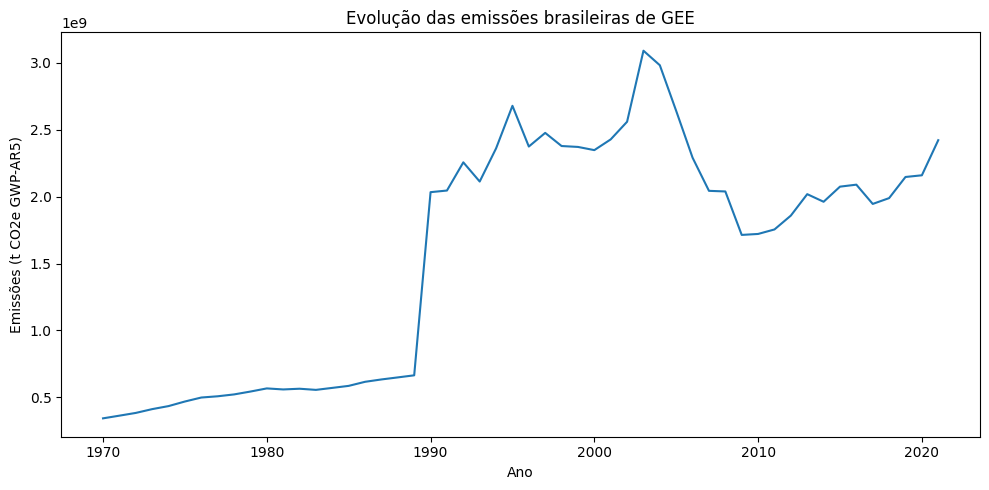

In [ ]:
ax = emissoes_brasil_ano.plot(
    x="ano",
    y="emissao_toneladas",
    kind="line",
    figsize=(10, 5),
    legend=False
)
ax.set_title("Evolução das emissões brasileiras de GEE")
ax.set_xlabel("Ano")
ax.set_ylabel("Emissões (t CO2e GWP-AR5)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "evolucao_emissoes_brasil.png", dpi=120)
plt.show()

### Insight inicial

A série temporal permite observar como as emissões variaram ao longo das décadas.  
Essa visão será importante para contextualizar análises futuras por setor, estado e região.

## 6. Emissões por setor

Agora analisamos quais setores mais contribuem para o total nacional no último ano disponível da base, somando os valores de todas as UFs.

In [ ]:
ultimo_ano = emissoes_long["ano"].max()
ultimo_ano

np.int64(2021)

In [ ]:
emissoes_setor_ultimo_ano = (
    emissoes_long
    .query("ano == @ultimo_ano")
    .groupby("Nível 1 - Setor", as_index=False)["emissao_toneladas"]
    .sum()
    .sort_values("emissao_toneladas", ascending=False)
)

emissoes_setor_ultimo_ano

,Nível 1 - Setor,emissao_toneladas
2,Mudança de Uso da Terra e Floresta,1188188576.00
0,Agropecuária,600759215.89
1,Energia,434607259.46
3,Processos Industriais,107948489.86
4,Resíduos,91121526.74


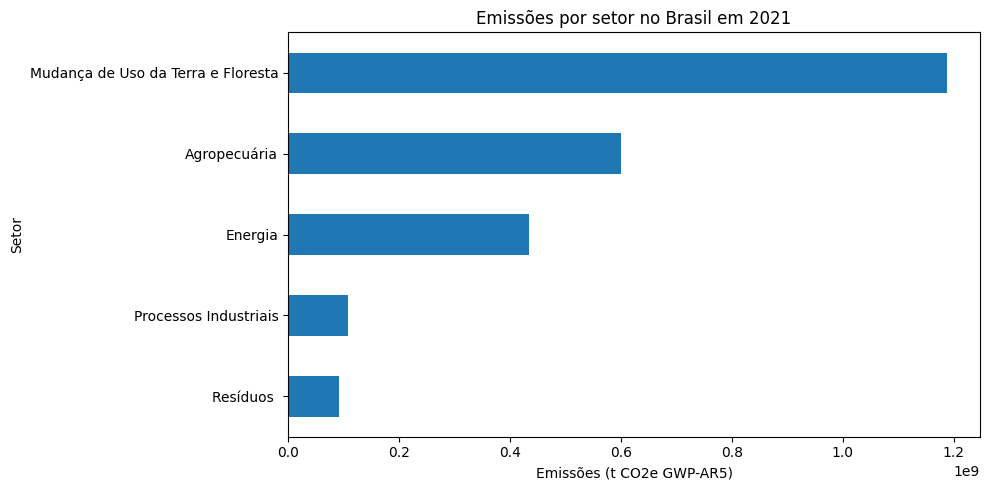

In [ ]:
ax = emissoes_setor_ultimo_ano.sort_values("emissao_toneladas").plot(
    kind="barh",
    x="Nível 1 - Setor",
    y="emissao_toneladas",
    figsize=(10, 5),
    legend=False
)
ax.set_title(f"Emissões por setor no Brasil em {ultimo_ano}")
ax.set_xlabel("Emissões (t CO2e GWP-AR5)")
ax.set_ylabel("Setor")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "emissoes_por_setor.png", dpi=120)
plt.show()

### Insight inicial

A análise setorial ajuda a entender **onde estão os principais focos de emissão**.  
Esse recorte é importante porque permite discutir o problema para além do ranking de estados, conectando emissões a atividades econômicas e uso do território.

## 7. Emissões por unidade federativa

Para comparar estados, calculamos as emissões totais por UF no último ano disponível.

In [ ]:
emissoes_uf_ultimo_ano = (
    emissoes_long
    .query("ano == @ultimo_ano")
    .groupby("Estado", as_index=False)["emissao_toneladas"]
    .sum()
    .sort_values("emissao_toneladas", ascending=False)
)

emissoes_uf_ultimo_ano.head(10)

,Estado,emissao_toneladas
13,PA,447927370.47
12,MT,269374499.56
10,MG,168233656.95
25,SP,156729716.61
2,AM,138845369.16
20,RO,137889786.89
9,MA,117153454.45
22,RS,107764641.99
8,GO,92896270.29
17,PR,86285774.44


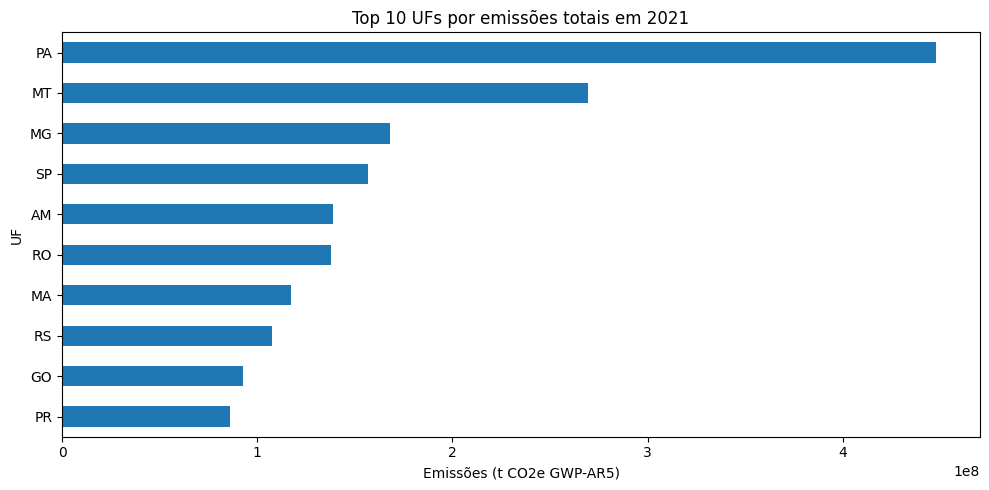

In [ ]:
ax = emissoes_uf_ultimo_ano.head(10).sort_values("emissao_toneladas").plot(
    kind="barh",
    x="Estado",
    y="emissao_toneladas",
    figsize=(10, 5),
    legend=False
)
ax.set_title(f"Top 10 UFs por emissões totais em {ultimo_ano}")
ax.set_xlabel("Emissões (t CO2e GWP-AR5)")
ax.set_ylabel("UF")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "top10_ufs_emissoes_totais.png", dpi=120)
plt.show()

### Insight inicial

O ranking absoluto mostra quais estados concentram maior volume total de emissões.  
Porém, essa leitura ainda não considera o tamanho da população, então estados mais populosos ou com maior atividade econômica podem aparecer naturalmente em destaque.

## 8. Preparação da população por UF

A base do IBGE está em nível municipal. Para calcular emissão per capita, agregamos a população por UF.

Alguns valores de população podem conter marcações textuais/observações entre parênteses. Por isso, removemos esses caracteres antes da conversão para número.

In [ ]:
populacao_raw.head()

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
0,RO,11,15,Alta Floresta D'Oeste,21558
1,RO,11,23,Ariquemes,100896
2,RO,11,31,Cabixi,5107
3,RO,11,49,Cacoal,92202
4,RO,11,56,Cerejeiras,15237


In [ ]:
populacao_estados = populacao_raw.copy()

populacao_estados["populacao"] = (
    populacao_estados["POPULAÇÃO"]
    .astype(str)
    .str.replace(r"\(\d+\)", "", regex=True)
    .str.replace(".", "", regex=False)
    .str.strip()
)

populacao_estados["populacao"] = pd.to_numeric(populacao_estados["populacao"], errors="coerce")

populacao_uf = (
    populacao_estados
    .groupby("UF", as_index=False)["populacao"]
    .sum()
)

populacao_uf.head()

,UF,populacao
0,AC,829780
1,AL,3125254
2,AM,3952262
3,AP,774268
4,BA,14659023


In [ ]:
populacao_uf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   UF         27 non-null     object
 1   populacao  27 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 564.0+ bytes


## 9. Emissão per capita

Com as emissões por UF e a população por UF, podemos construir uma métrica mais comparável entre estados:

```text
emissão per capita = emissão total da UF / população da UF
```

> Observação metodológica: a base SEEG utilizada vai até o último ano disponível no arquivo, enquanto a base populacional é de 2022. Nesta etapa, a população de 2022 é usada como referência aproximada para contextualizar as emissões estaduais do último ano disponível.

In [ ]:
emissoes_per_capita = (
    emissoes_uf_ultimo_ano
    .merge(populacao_uf, left_on="Estado", right_on="UF", how="inner")
    .assign(emissao_per_capita=lambda df: df["emissao_toneladas"] / df["populacao"])
    .sort_values("emissao_per_capita", ascending=False)
)

emissoes_per_capita.head(10)

,Estado,emissao_toneladas,UF,populacao,emissao_per_capita
13,RR,61577273.73,RR,634805,97.00
5,RO,137889786.89,RO,1616379,85.31
1,MT,269374499.56,MT,3784239,71.18
0,PA,447927370.47,PA,8442962,53.05
16,AC,43995710.97,AC,829780,53.02
15,TO,56648514.50,TO,1584306,35.76
4,AM,138845369.16,AM,3952262,35.13
10,MS,81499354.70,MS,2833742,28.76
6,MA,117153454.45,MA,6800605,17.23
8,GO,92896270.29,GO,6950976,13.36


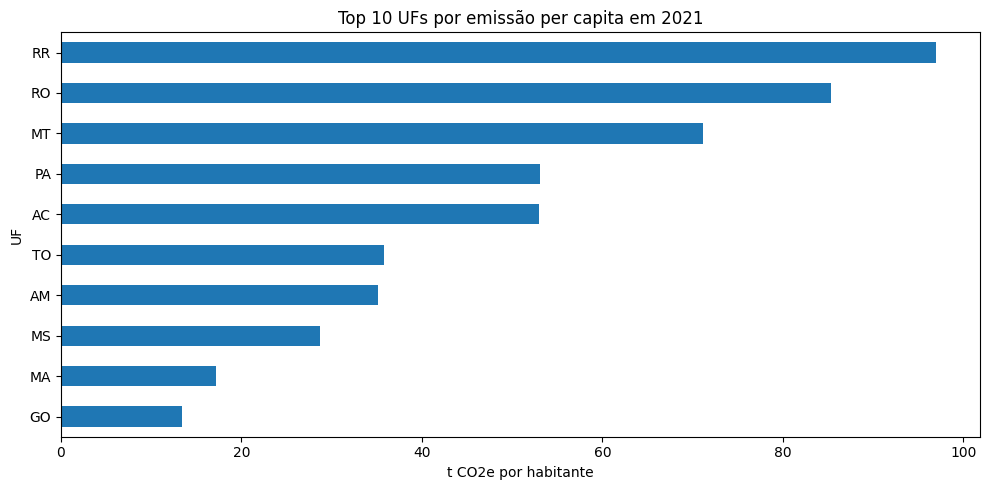

In [ ]:
ax = emissoes_per_capita.head(10).sort_values("emissao_per_capita").plot(
    kind="barh",
    x="Estado",
    y="emissao_per_capita",
    figsize=(10, 5),
    legend=False
)
ax.set_title(f"Top 10 UFs por emissão per capita em {ultimo_ano}")
ax.set_xlabel("t CO2e por habitante")
ax.set_ylabel("UF")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "top10_ufs_emissao_per_capita.png", dpi=120)
plt.show()

### Insight inicial

A análise per capita é um dos pontos centrais do projeto.  
Ela permite comparar estados de tamanhos populacionais diferentes e pode revelar UFs que não lideram em emissões absolutas, mas possuem impacto proporcional elevado.

## 10. Comparando ranking absoluto e per capita

Uma comparação importante é observar se os estados que mais emitem em termos absolutos também aparecem entre os maiores emissores per capita.

In [ ]:
comparacao_rankings = (
    emissoes_per_capita
    .assign(
        ranking_emissao_total=lambda df: df["emissao_toneladas"].rank(ascending=False, method="min").astype(int),
        ranking_emissao_per_capita=lambda df: df["emissao_per_capita"].rank(ascending=False, method="min").astype(int)
    )
    .sort_values("ranking_emissao_per_capita")
)

comparacao_rankings[[
    "Estado", "emissao_toneladas", "populacao", "emissao_per_capita",
    "ranking_emissao_total", "ranking_emissao_per_capita"
]].head(15)

,Estado,emissao_toneladas,populacao,emissao_per_capita,ranking_emissao_total,ranking_emissao_per_capita
13,RR,61577273.73,634805,97.00,14,1
5,RO,137889786.89,1616379,85.31,6,2
1,MT,269374499.56,3784239,71.18,2,3
0,PA,447927370.47,8442962,53.05,1,4
16,AC,43995710.97,829780,53.02,17,5
15,TO,56648514.50,1584306,35.76,16,6
4,AM,138845369.16,3952262,35.13,5,7
10,MS,81499354.70,2833742,28.76,11,8
6,MA,117153454.45,6800605,17.23,7,9
8,GO,92896270.29,6950976,13.36,9,10


### Insight inicial

Essa comparação ajuda a evitar conclusões simplistas.  
Um estado pode ter emissão total alta por concentrar população e atividade econômica, mas a emissão per capita mostra outra perspectiva: a intensidade de emissão em relação ao tamanho populacional.

## 11. Exportação dos dados tratados

Por fim, salvamos as bases processadas para reutilização em etapas futuras do projeto, como visualizações, SQL, Power BI ou Streamlit.

In [ ]:
emissoes_long.to_csv(PROCESSED_DIR / "emissoes_long_co2e_gwp_ar5.csv", index=False)
emissoes_brasil_ano.to_csv(PROCESSED_DIR / "emissoes_brasil_ano.csv", index=False)
emissoes_setor_ultimo_ano.to_csv(PROCESSED_DIR / "emissoes_setor_ultimo_ano.csv", index=False)
emissoes_uf_ultimo_ano.to_csv(PROCESSED_DIR / "emissoes_uf_ultimo_ano.csv", index=False)
emissoes_per_capita.to_csv(PROCESSED_DIR / "emissoes_per_capita_uf.csv", index=False)
comparacao_rankings.to_csv(PROCESSED_DIR / "comparacao_rankings_uf.csv", index=False)

print("Arquivos exportados para:", PROCESSED_DIR)

Arquivos exportados para: /mnt/data/test_project/data/processed


## 12. Conclusão da primeira versão

Nesta primeira etapa do projeto, estruturamos a base de emissões para análise e criamos os principais recortes necessários para uma narrativa de portfólio:

- filtragem de registros relevantes de emissão;
- seleção de uma métrica única de CO2e para evitar dupla contagem;
- transformação da base de formato largo para longo;
- análise temporal nacional;
- análise setorial;
- análise por UF;
- integração com população do IBGE;
- cálculo de emissão per capita;
- exportação de bases processadas para uso futuro.

### Próximos passos

1. Refinar visualizações e storytelling no README.
2. Adicionar análise regional.
3. Criar uma camada em Power BI usando os CSVs processados.
4. Futuramente, evoluir o projeto com SQL, mapas e Streamlit.